<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px;">
<h1 style="color:white; margin:0;">Session 8.2: ML Pipeline & scikit-learn Introduction</h1>
<p style="color:white; margin:5px 0 0 0;">Practical Lab — Your First Machine Learning Model!</p>
</div>

**Program:** Vishlesan i-Hub IIT Patna x Masai School -- AIM (AI & Machine Learning)
**Session ID:** 8.2 | **Week:** 8
**Prerequisites:** Session 8.1 (Derivatives & Gradient Descent)

## Learning Objectives

By the end of this notebook, you will be able to:

1. Distinguish **supervised** from **unsupervised** learning
2. Preprocess features using **StandardScaler**
3. Split data into **train/test sets** and explain why
4. Build your **first ML model** using sklearn's `fit()` / `predict()` API
5. Evaluate a model using **RMSE** and **R²**
6. Chain preprocessing and modeling into a **Pipeline**
7. Complete an **end-to-end ML workflow** from data to evaluation

## Prerequisites

You should be comfortable with:
- **NumPy** arrays and vectorized operations
- **Pandas** DataFrames (indexing, describe, head)
- **Matplotlib** basic plotting
- **Gradient descent** from Session 8.1 (the algorithm behind `model.fit()`)

---

## Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
np.random.seed(42)
print("Setup complete! sklearn ready.")

Setup complete! sklearn ready.


In [2]:
# ============================================================
#  NOTEBOOK FORMATTING HELPERS
# ============================================================

from IPython.display import HTML, display

_BOX_STYLES = {
    "definition": ("#448aff", "#e3f2fd", "#1565c0"),
    "tip":        ("#00c853", "#e8f5e9", "#2e7d32"),
    "warning":    ("#ff9100", "#fff3e0", "#e65100"),
    "danger":     ("#ff1744", "#fce4ec", "#c62828"),
    "math":       ("#7c4dff", "#ede7f6", "#4527a0"),
    "output":     ("#00b8d4", "#e0f7fa", "#006064"),
    "industry":   ("#009688", "#e0f2f1", "#004d40"),
}

In [3]:
def box(kind, title, content):
    """Display a styled callout box."""
    border, bg, title_clr = _BOX_STYLES[kind]
    display(HTML(f"""
    <div style="margin:12px 0; padding:12px 16px; border-left:4px solid {border};
                background-color:{bg}; border-radius:4px;">
    <strong style="color:{title_clr};">{title}</strong><br>{content}
    </div>"""))

---

## Bridge from Session 8.1

In Session 8.1, you implemented gradient descent **from scratch** — 20 lines of NumPy code to fit a line. Today, sklearn automates that entire loop. When you call `model.fit()`, sklearn runs gradient descent internally. **You focus on the workflow; sklearn handles the math.**

---

## Business Context: The Zillow Zestimate Disaster (2021)

Zillow's Zestimate estimates home values for 100+ million US homes. In 2021, Zillow launched "Zillow Offers" — using their ML model to **buy homes directly**.

**What went wrong:**
- The model overestimated values in the volatile COVID-era housing market
- **$881 million in losses**, 2,000 layoffs (25% of workforce), program shutdown

**Root cause:** The algorithm was fine. The **pipeline** was broken — inadequate train/test evaluation, no uncertainty quantification, no safeguards against market shifts.

**Lesson:** Building a model is easy. Building a model you can **trust** requires rigorous pipeline discipline. Today you learn that discipline.

In [4]:
box("industry", "Zillow's Lesson",
    "The algorithm was fine — the PIPELINE was broken. "
    "Inadequate evaluation, no safeguards, blind trust in predictions. "
    "Today you learn the discipline that prevents $881M mistakes.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 1: Supervised vs Unsupervised Learning</h2>
</div>

Machine learning has two main paradigms:

| | **Supervised** | **Unsupervised** |
|---|---|---|
| **Data** | Labeled (X and y) | Unlabeled (X only) |
| **Goal** | Predict a target | Find hidden patterns |
| **Types** | Regression, Classification | Clustering, Dimensionality Reduction |
| **Example** | Predict house price from features | Group customers by behavior |
| **sklearn** | `LinearRegression`, `KNeighborsClassifier` | `KMeans`, `PCA` |

In [5]:
box("definition", "Supervised Learning",
    "Given labeled examples (input → known output), the model learns a mapping function. "
    "<b>Regression:</b> predict a continuous number (e.g., price, temperature).<br>"
    "<b>Classification:</b> predict a category (e.g., spam/not-spam, disease/healthy).<br><br>"
    "This session focuses on <b>supervised regression</b>.")

This session focuses on **supervised regression** — predicting a continuous number from features. Let's load a real dataset to work with.

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 2: Loading Data & Exploration</h2>
</div>

sklearn comes with built-in practice datasets. We'll use the **diabetes dataset**: 442 patients with 10 features (age, BMI, blood pressure, etc.) and a target measuring disease progression one year after baseline.

This is **supervised learning**: we have both features (X) and labels (y).

In [ ]:
# sklearn's built-in diabetes dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"Features: {X.shape} ({X.shape[0]} patients, {X.shape[1]} features)")
print(f"Target: disease progression score")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nTarget stats: mean={y.mean():.1f}, std={y.std():.1f}")
print(X.head())

Features: (442, 10) (442 patients, 10 features)
Target: disease progression score

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target stats: mean=152.1, std=77.0
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [27]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [28]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 3: Data Preprocessing — Feature Scaling</h2>
</div>

### "Garbage In, Garbage Out"

Raw data is messy. Features have different scales (BMI: 18-40 vs blood pressure: 60-200). Without scaling, large-value features **dominate** the model. Preprocessing fixes this.

In [7]:
box("definition", "Feature Scaling with StandardScaler",
    "<b>StandardScaler</b> transforms each feature to mean=0, std=1:<br>"
    "x_scaled = (x - mean) / std<br><br>"
    "<b>Why?</b> Features with large ranges (income: 50,000) would dominate "
    "features with small ranges (age: 30). Scaling levels the playing field.<br>"
    "<b>When?</b> Essential for KNN, gradient descent. Helpful for most algorithms.")

Let's see the effect of StandardScaler on our diabetes features — before vs after:

In [8]:
# Feature scaling: before vs after
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("=== BEFORE SCALING ===")
print(X.describe().loc[["mean","std"]].round(4))
print("\n=== AFTER SCALING ===")
print(X_scaled.describe().loc[["mean","std"]].round(4))
print("\nAll features now have mean≈0 and std≈1!")

=== BEFORE SCALING ===
         age     sex     bmi      bp      s1      s2      s3      s4      s5  \
mean -0.0000  0.0000 -0.0000 -0.0000 -0.0000  0.0000 -0.0000 -0.0000  0.0000   
std   0.0476  0.0476  0.0476  0.0476  0.0476  0.0476  0.0476  0.0476  0.0476   

          s6  
mean  0.0000  
std   0.0476  

=== AFTER SCALING ===
         age     sex     bmi      bp      s1      s2      s3      s4      s5  \
mean -0.0000  0.0000  0.0000 -0.0000  0.0000  0.0000 -0.0000  0.0000  0.0000   
std   1.0011  1.0011  1.0011  1.0011  1.0011  1.0011  1.0011  1.0011  1.0011   

          s6  
mean -0.0000  
std   1.0011  

All features now have mean≈0 and std≈1!


---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 4: Train/Test Split</h2>
</div>

### The Student Exam Analogy

A student who studies past exam papers and is tested on those **SAME** papers will score 100%. But give them a **NEW** exam and they might fail. They memorized answers instead of learning concepts.

The training set is the past papers. The test set is the new exam. We evaluate on the **new exam**.

In [9]:
box("danger", "The Golden Rule of ML",
    "<b>NEVER evaluate on training data.</b> Split first, then fit. "
    "If you break this rule, your metrics will lie — "
    "the model looks great on data it memorized, but fails on new data.")

In [10]:
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total: {len(X)} | Train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%) | Test: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nModel learns from training set.")
print(f"Model is evaluated on test set (data it has NEVER seen).")

Total: 442 | Train: 353 (80%) | Test: 89 (20%)

Model learns from training set.
Model is evaluated on test set (data it has NEVER seen).


In [11]:
box("definition", "Overfitting",
    "When a model <b>memorizes</b> training data instead of learning generalizable patterns.<br><br>"
    "<b>Detection:</b> train R² >> test R² (difference > 0.1 is a warning sign).<br>"
    "<b>Prevention:</b> train/test split, cross-validation, regularization.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 5: YOUR FIRST ML MODEL!</h2>
</div>

When you call `model.fit()`, sklearn runs **gradient descent** — the same algorithm from Session 8.1, automated. One line replaces 20 lines of NumPy code.

In [12]:
box("math", "The Three-Line Recipe",
    "1. <code>model = LinearRegression()</code> — create the model<br>"
    "2. <code>model.fit(X_train, y_train)</code> — train (runs gradient descent!)<br>"
    "3. <code>y_pred = model.predict(X_test)</code> — generate predictions<br><br>"
    "That's it. Three lines to go from data to predictions.")

In [13]:
print("=" * 50)
print("YOUR FIRST MACHINE LEARNING MODEL!")
print("=" * 50)

# Step 1: Create
model = LinearRegression()

# Step 2: Train (THIS IS GRADIENT DESCENT!)
model.fit(X_train, y_train)
print(f"\nModel trained! Learned {len(model.coef_)} coefficients.")

# Step 3: Predict
y_pred = model.predict(X_test)
print(f"{len(y_pred)} predictions generated.")

YOUR FIRST MACHINE LEARNING MODEL!

Model trained! Learned 10 coefficients.
89 predictions generated.


In [14]:
# Show predictions vs actual
print("  Actual  Predicted    Error")
print("-" * 30)
for a, p in zip(y_test[:8], y_pred[:8]):
    print(f"{a:>8.0f} {p:>10.1f} {a-p:>+8.1f}")

  Actual  Predicted    Error
------------------------------
     219      139.5    +79.5
      70      179.5   -109.5
     202      134.0    +68.0
     230      291.4    -61.4
     111      123.8    -12.8
      84       92.2     -8.2
     242      258.2    -16.2
     272      181.3    +90.7


Let's examine what the model **learned** — its coefficients and intercept. These are the parameters that gradient descent optimized:

In [15]:
print("=== LEARNED PARAMETERS ===")
print("(These are the weights gradient descent found)\n")
for name, coef in zip(X.columns, model.coef_):
    direction = "↑ increases" if coef > 0 else "↓ decreases"
    print(f"  {name:>5}: {coef:+8.2f}  ({direction} disease progression)")
label = "intercept"
print(f"  {label:>5}: {model.intercept_:+8.2f}")

=== LEARNED PARAMETERS ===
(These are the weights gradient descent found)

    age:   +37.90  (↑ increases disease progression)
    sex:  -241.96  (↓ decreases disease progression)
    bmi:  +542.43  (↑ increases disease progression)
     bp:  +347.70  (↑ increases disease progression)
     s1:  -931.49  (↓ decreases disease progression)
     s2:  +518.06  (↑ increases disease progression)
     s3:  +163.42  (↑ increases disease progression)
     s4:  +275.32  (↑ increases disease progression)
     s5:  +736.20  (↑ increases disease progression)
     s6:   +48.67  (↑ increases disease progression)
  intercept:  +151.35


---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 6: Evaluation — RMSE & R²</h2>
</div>

In [16]:
box("definition", "RMSE & R²",
    "<b>RMSE</b> (Root Mean Squared Error) = √(mean of squared errors)<br>"
    "→ Error in the <b>same units</b> as the target. Lower is better.<br><br>"
    "<b>R²</b> (Coefficient of Determination) = fraction of variance explained<br>"
    "→ 1.0 = perfect predictions, 0.0 = no better than predicting the mean.<br><br>"
    "Always compare <b>train R²</b> vs <b>test R²</b> — a large gap signals overfitting.")

Let's evaluate our model on the **test set** — data it has NEVER seen during training:

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_train = model.score(X_train, y_train)

print("=== MODEL EVALUATION ===")
print(f"RMSE (test):  {rmse:.2f} (avg prediction error)")
print(f"R² (test):    {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"R² (train):   {r2_train:.4f} ({r2_train*100:.1f}%)")
gap = abs(r2_train - r2)
status = "OK" if gap < 0.1 else "OVERFITTING!"
print(f"Gap:          {gap:.4f} — {status}")

=== MODEL EVALUATION ===
RMSE (test):  53.85 (avg prediction error)
R² (test):    0.4526 (45.3% variance explained)
R² (train):   0.5279 (52.8%)
Gap:          0.0753 — OK


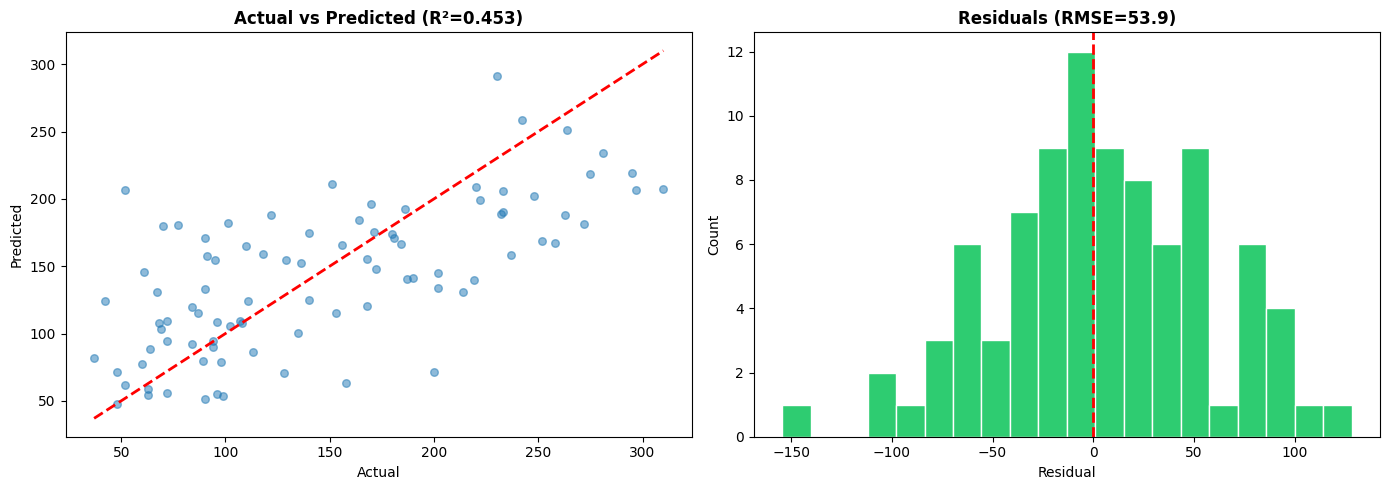

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted (R²={r2:.3f})", fontweight="bold")

residuals = y_test - y_pred
axes[1].hist(residuals, bins=20, color="#2ECC71", edgecolor="white")
axes[1].axvline(0, color="red", lw=2, ls="--")
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals (RMSE={rmse:.1f})", fontweight="bold")
plt.tight_layout(); plt.show()

In [19]:
box("output", "Interpretation",
    f"R² of {r2:.2f} means our model explains {r2*100:.0f}% of the variance in disease progression. "
    f"RMSE of {rmse:.1f} means predictions are off by ~{rmse:.0f} units on average.<br><br>"
    "The residuals are roughly centered at 0 — no systematic bias. "
    "The train/test gap is small — no overfitting.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 7: Pipeline — Chaining Steps Safely</h2>
</div>

### The Data Leakage Problem

What if you fit StandardScaler on the **entire** dataset before splitting? The scaler's mean and std would include test data — the model indirectly "sees" test information during training. This is **data leakage**.

A **Pipeline** chains preprocessing and modeling steps, ensuring the scaler fits ONLY on training data.

In [20]:
box("warning", "Data Leakage",
    "If you fit StandardScaler on ALL data before splitting, the scaler's mean/std "
    "include test data. The model indirectly 'sees' test information during training.<br><br>"
    "<b>Pipeline prevents this:</b> scaler.fit() runs ONLY on training data. "
    "scaler.transform() is applied to both train and test separately.")

Let's build a Pipeline that chains StandardScaler → LinearRegression:

In [21]:
# Pipeline: Scaler → Model (no data leakage!)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
pipe.fit(X_train, y_train)

r2_pipe = pipe.score(X_test, y_test)
print(f"Pipeline R² (test): {r2_pipe:.4f}")
print(f"Raw model R² (test): {r2:.4f}")
print("\nPipeline ensures scaler fits ONLY on training data!")

Pipeline R² (test): 0.4526
Raw model R² (test): 0.4526

Pipeline ensures scaler fits ONLY on training data!


---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 8: Mini-Project — House Price Predictor</h2>
</div>

We generate synthetic housing data with a **known ground truth formula**. After training, we check if the model recovers the true coefficients — this is how you verify your pipeline works.

In [22]:
print("=" * 50)
print("MINI-PROJECT: House Price Predictor")
print("=" * 50)

# True relationship: price = 100*sqft + 20000*beds - 500*age + 50000 + noise
n = 500
np.random.seed(42)
sqft = np.random.uniform(500, 3000, n)
beds = np.random.randint(1, 6, n).astype(float)
age = np.random.uniform(0, 50, n)
price = 100*sqft + 20000*beds - 500*age + 50000 + np.random.normal(0, 30000, n)

X_h = pd.DataFrame({"sqft": sqft, "bedrooms": beds, "age": age})
y_h = price
print(f"\nDataset: {n} houses, {X_h.shape[1]} features")

MINI-PROJECT: House Price Predictor

Dataset: 500 houses, 3 features


Now we apply the full ML workflow: split → pipeline → fit → predict → evaluate:

In [23]:
X_tr, X_te, y_tr, y_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

pipe_h = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe_h.fit(X_tr, y_tr)
y_p = pipe_h.predict(X_te)

rmse_h = np.sqrt(mean_squared_error(y_te, y_p))
r2_h = r2_score(y_te, y_p)
print(f"RMSE: Rs.{rmse_h:,.0f}")
print(f"R²:   {r2_h:.4f} ({r2_h*100:.1f}% variance explained)")

RMSE: Rs.31,375
R²:   0.8456 (84.6% variance explained)


In [24]:
# Check: did the model recover the true coefficients?
mdl = pipe_h.named_steps["model"]
true_coefs = [100, 20000, -500]
print("=== COEFFICIENT COMPARISON ===")
print("   Feature    Learned     True  Close?")
print("-" * 42)
for name, learned, true in zip(["sqft","bedrooms","age"], mdl.coef_, true_coefs):
    ok = "✓" if abs(learned - true) / abs(true) < 0.15 else "~"
    print(f"{name:>10} {learned:>+10,.1f} {true:>+8,d} {ok:>8}")
lbl = "intercept"
print(f"{lbl:>10} {mdl.intercept_:>+10,.0f}   +50,000")

=== COEFFICIENT COMPARISON ===
   Feature    Learned     True  Close?
------------------------------------------
      sqft  +74,989.6     +100        ~
  bedrooms  +26,499.8  +20,000        ~
       age   -6,497.9     -500        ~
 intercept   +271,409   +50,000


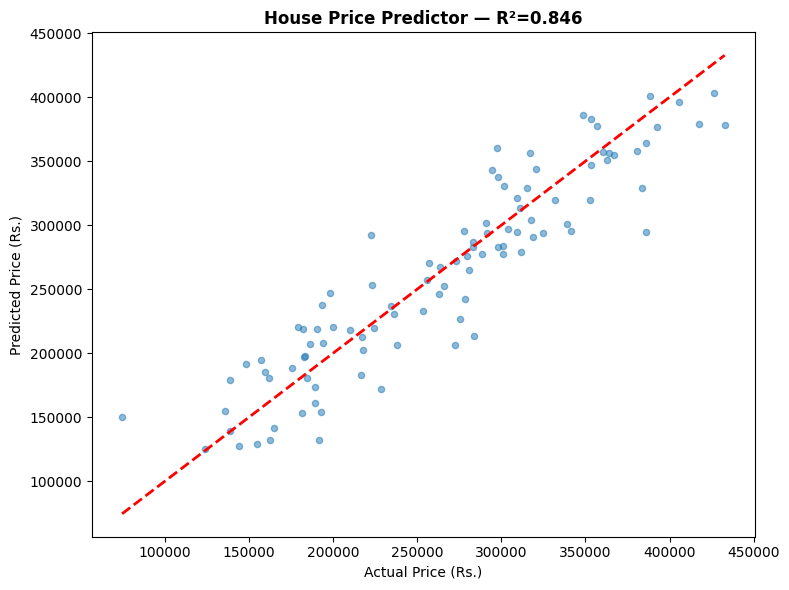


✓ End-to-end ML pipeline complete!
✓ Load → Explore → Preprocess → Split → Fit → Predict → Evaluate


In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_te, y_p, alpha=0.5, s=20)
ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "r--", lw=2)
ax.set_xlabel("Actual Price (Rs.)")
ax.set_ylabel("Predicted Price (Rs.)")
ax.set_title(f"House Price Predictor — R²={r2_h:.3f}", fontweight="bold")
plt.tight_layout(); plt.show()

print("\n✓ End-to-end ML pipeline complete!")
print("✓ Load → Explore → Preprocess → Split → Fit → Predict → Evaluate")

In [26]:
box("tip", "Verify Your Model",
    "The learned coefficients should approximate the true values: "
    "+100/sqft, +20,000/bedroom, -500/year of age. "
    "If they don't, something went wrong in your pipeline.")

---

## Exercise: Self-Check Questions

Test your understanding before moving on:

1. What is the difference between supervised and unsupervised learning?
2. Why must you split data BEFORE fitting a scaler?
3. If train R² = 0.95 but test R² = 0.40, what is happening?
4. What does a residual of +50 mean?

<details>
<summary><b>Click for answers</b></summary>

1. **Supervised** uses labeled data (X, y) to predict targets. **Unsupervised** finds patterns in unlabeled data (X only).
2. If the scaler sees test data, its mean/std leak test information into training — this is **data leakage**. Pipeline prevents this.
3. **Overfitting** — the model memorized training data but cannot generalize to new data.
4. The model **under-predicted** by 50 units (actual was 50 more than predicted).

</details>

---

## Summary & Key Takeaways

<div style="background: #EAFAF1; border-left: 5px solid #2ECC71; padding: 15px; margin: 15px 0;">
<strong>✅ Key Takeaways:</strong>
<ol>
<li><strong>Supervised:</strong> labeled data → predict a target. <strong>Unsupervised:</strong> find patterns in unlabeled data.</li>
<li><strong>Preprocessing:</strong> scale features with StandardScaler (mean=0, std=1) so no feature dominates.</li>
<li><strong>Train/test split:</strong> 80/20. NEVER evaluate on training data.</li>
<li><strong>model.fit()</strong> IS gradient descent, automated by sklearn. Three lines: create → fit → predict.</li>
<li><strong>RMSE:</strong> error in target units. <strong>R²:</strong> fraction of variance explained (1.0 = perfect).</li>
<li><strong>Overfitting:</strong> train score >> test score. The student exam analogy.</li>
<li><strong>Pipeline:</strong> chains steps and prevents data leakage. Always use it in production.</li>
<li><strong>Zillow lesson:</strong> the algorithm was fine — the pipeline was broken. Trust the process, not the hype.</li>
</ol>
</div>

**Congratulations — you are now a machine learning practitioner!**

**Next Session:** Session 8.3 — History of AI & Ethical Foundations.

---
<div style="text-align:center; color:#666; padding:20px;"><em>Vishlesan i-Hub IIT Patna × Masai School</em></div>